In [1]:
using Oceananigans
using JLD2
using CairoMakie
using CairoMakie.Colors
using Statistics

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

include("../src-fig/plotting.jl")
include("../setup/ensemble.jl");

[ Info: Oceananigans will use 4 threads


In [44]:
run_ids = cooling_only.filenames
qs = map(run_ids) do run_id
    PV = joinpath("../../scratch/turbulence-at-many-fronts", run_id, "PV.jld2")
    iterations, times = iterations_times(PV)
    sp = simulation_parameters(PV)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(PV)
    k = zᶠbounds(PV, -sp.H)
    data = timeseries_of(PV, "q", iterations) do field
        mean(field[:, k:end])
    end
end;

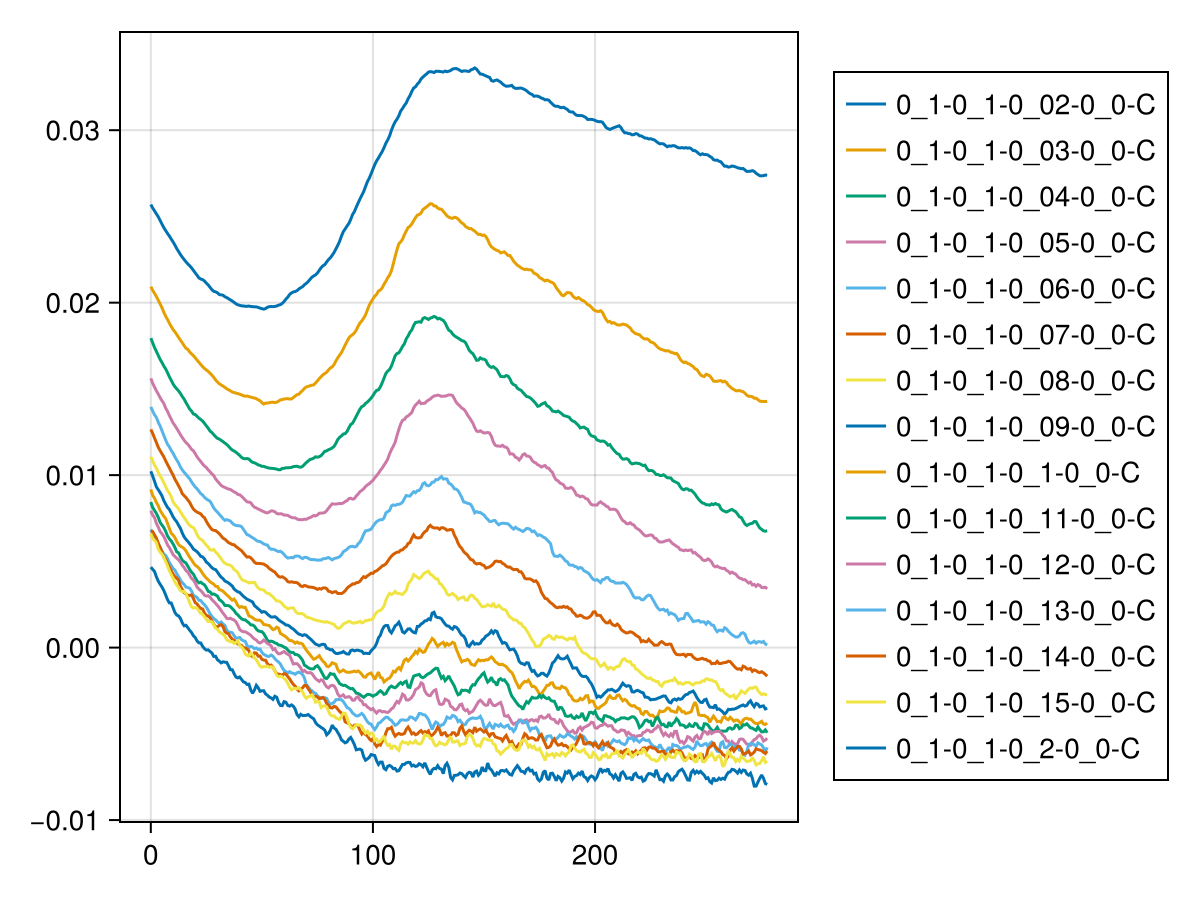

In [45]:
fig = Figure()
ax = Axis(fig[1, 1])
is = 2:length(run_ids)
lns = map(is) do i
    PV = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i], "PV.jld2")
    iterations, times = iterations_times(PV)
    sp = simulation_parameters(PV)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(PV)
    inds = center_indices(PV)
    data = qs[i] ./ (sp.f * sp.N₀²) #(qs[i] .- qs[i][1]) ./ (sp.B * sp.f)
    lines!(ax, times ./ 3600, data)
end
Legend(fig[1, 2], lns, run_ids[is])
fig

In [50]:
run_ids = cooling_only.filenames
wqs = map(run_ids) do run_id
    PV = joinpath("../../scratch/turbulence-at-many-fronts", run_id, "PV.jld2")
    iterations, times = iterations_times(PV)
    sp = simulation_parameters(PV)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(PV)
    k = zᶠbounds(PV, -0.05sp.H)
    data = time_average_of(PV, "J_mix_z", iterations[end-10:end]) do field
        field[:, k]
    end
end;

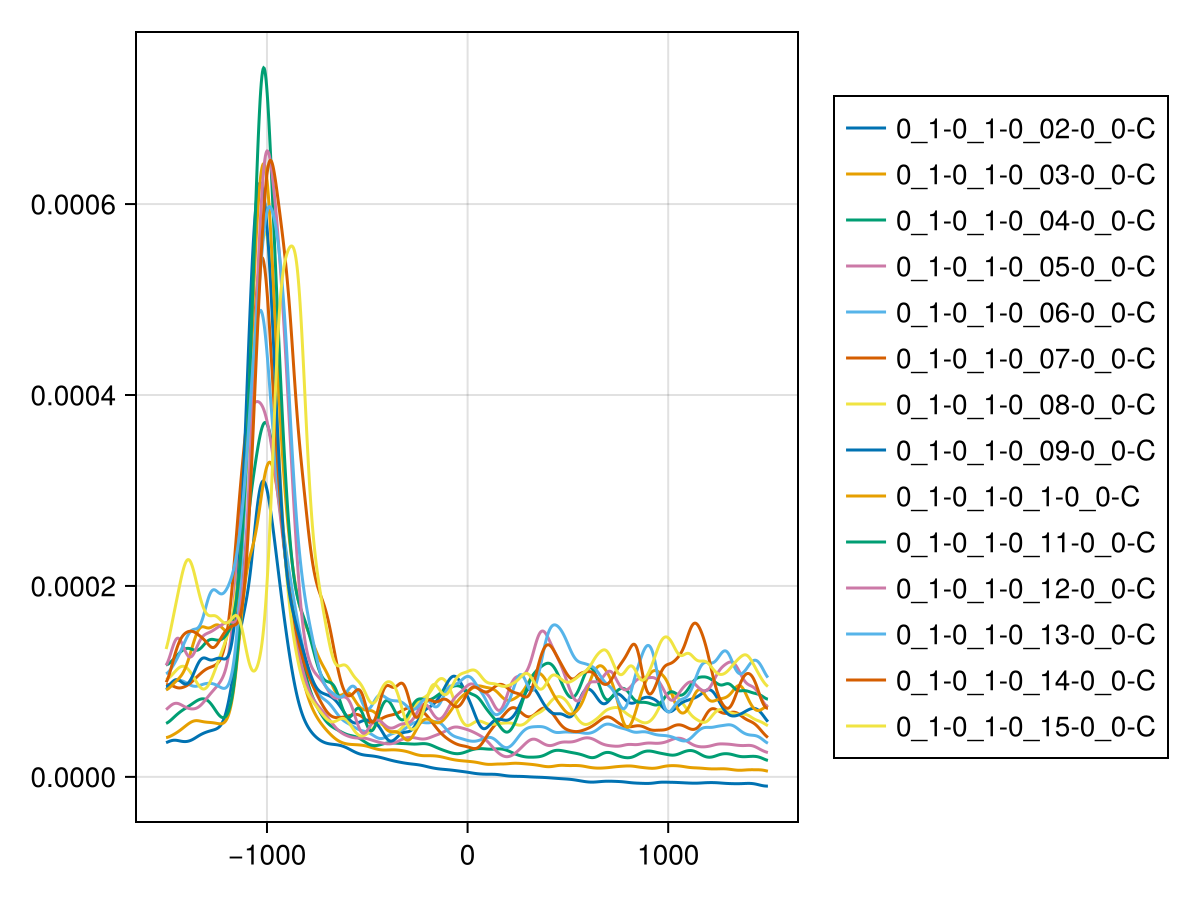

In [54]:
fig = Figure()
ax = Axis(fig[1, 1])
is = 2:length(run_ids)-1
lns = map(is) do i
    PV = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i], "PV.jld2")
    iterations, times = iterations_times(PV)
    sp = simulation_parameters(PV)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(PV)
    inds = center_indices(PV)
    data = wqs[i] ./ (sp.f * sp.N₀²) #(qs[i] .- qs[i][1]) ./ (sp.B * sp.f)
    lines!(ax, xsᶠ[inds], data[inds])
end
Legend(fig[1, 2], lns, run_ids[is])
fig

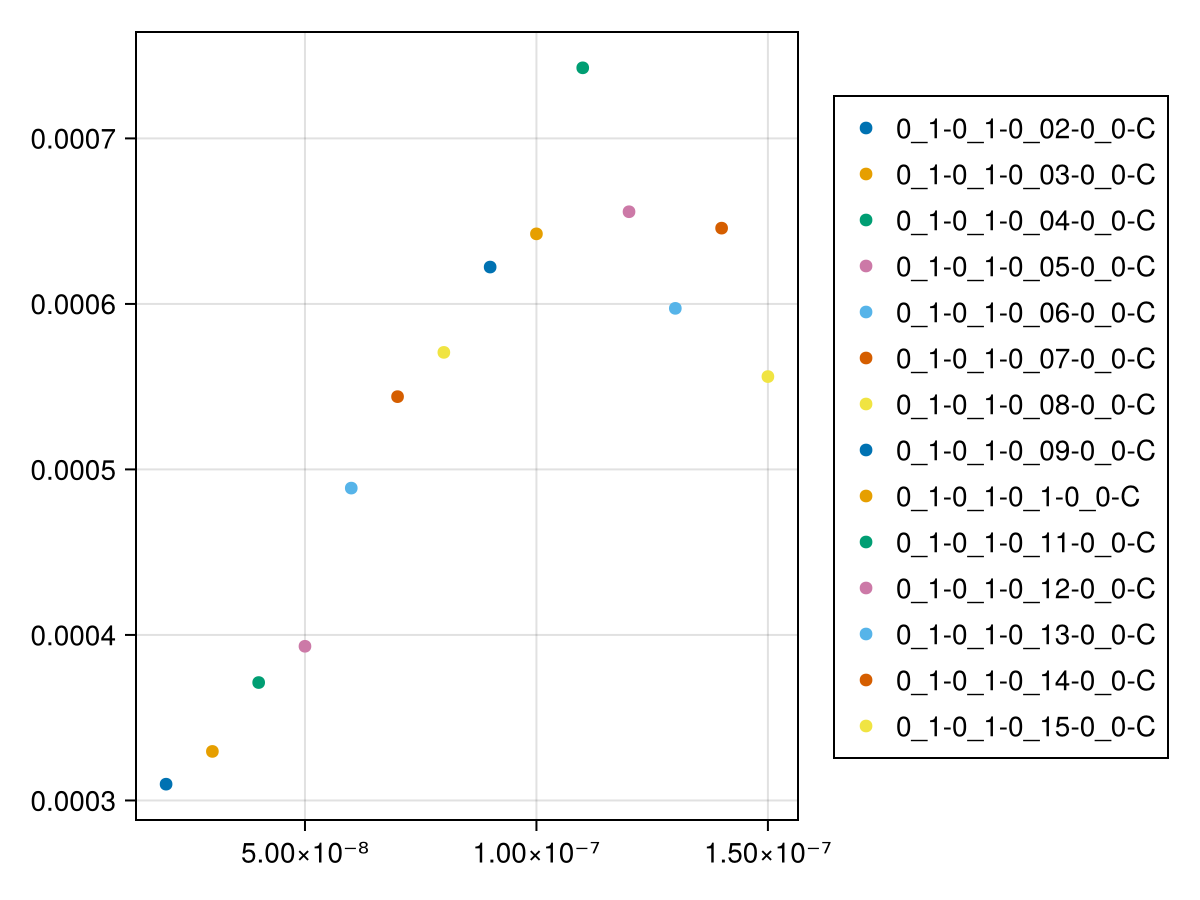

In [55]:
fig = Figure()
ax = Axis(fig[1, 1])
is = 2:length(run_ids)-1
lns = map(is) do i
    PV = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i], "PV.jld2")
    iterations, times = iterations_times(PV)
    sp = simulation_parameters(PV)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(PV)
    inds = center_indices(PV)
    data = wqs[i] ./ (sp.f * sp.N₀²) #(qs[i] .- qs[i][1]) ./ (sp.B * sp.f)
    scatter!(ax, sp.B, maximum(data[inds]))
end
Legend(fig[1, 2], lns, run_ids[is])
fig